In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2



In [2]:
sample = pd.read_csv("../input/petfinder-pawpularity-score/sample_submission.csv")
sample



,Id,Pawpularity
0,ee51b99832f1ba868f646df93d2b6b81,64.06
1,caddfb3f8bff9c4b95dbe022018eea21,27.71
2,582eeabd4a448a53ebb79995888a4b0b,5.06
3,afc1ad7f0c5eea880759d09e77f7deee,2.64
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,81.51
...,...,...
987,46bcb1c4ca0b78c584d7a65e1b4b2590,8.30
988,8064261ce5f7197fdc849641b3192eef,68.64
989,a5ff4923e393fa08e67da31c7eb4edd5,80.13
990,fa6a53f962225c17b22392748f91f9ac,64.54


In [3]:
test = pd.read_csv("../input/petfinder-pawpularity-score/test.csv")
test



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur
0,ee51b99832f1ba868f646df93d2b6b81,0,1,1,1,0,0,0,0,0,0,0,0
1,caddfb3f8bff9c4b95dbe022018eea21,0,0,1,1,0,1,1,0,0,0,0,0
2,582eeabd4a448a53ebb79995888a4b0b,0,1,1,0,0,0,0,0,0,0,0,0
3,afc1ad7f0c5eea880759d09e77f7deee,0,1,1,1,0,0,0,0,0,0,0,0
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,0,1,1,0,0,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,46bcb1c4ca0b78c584d7a65e1b4b2590,0,1,1,1,0,0,1,0,0,0,0,0
988,8064261ce5f7197fdc849641b3192eef,0,1,1,1,0,0,0,0,0,1,0,0
989,a5ff4923e393fa08e67da31c7eb4edd5,0,1,1,1,0,0,0,0,0,0,0,0
990,fa6a53f962225c17b22392748f91f9ac,0,1,1,1,0,0,0,0,0,0,0,0


In [4]:
train = pd.read_csv("../input/petfinder-pawpularity-score/train.csv")
train



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8915,ee97d86d26506239666d3679ff4a73aa,0,0,1,1,0,0,0,0,0,0,0,1,31
8916,7cf13d655a8d0d6a1d636c3920d49e86,0,0,1,1,0,0,0,0,0,0,0,0,33
8917,547e443edbf94b3646ff110324846bae,0,1,1,0,0,0,1,0,0,0,0,0,27
8918,fe2b587f649b9780900246c4b174a231,0,1,1,1,0,0,1,0,0,0,0,0,27


In [5]:
train_path = "../input/petfinder-pawpularity-score/train"



In [6]:
path = os.path.join(train_path, train["Id"].iloc[0] + ".jpg")



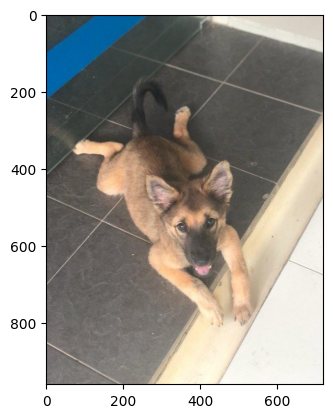

In [7]:
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)



In [8]:
train.iloc[0]



Id               1a8795e64a294ed0c95132e18ee198e1
Subject Focus                                   0
Eyes                                            1
Face                                            1
Near                                            1
Action                                          0
Accessory                                       0
Group                                           0
Collage                                         0
Human                                           0
Occlusion                                       0
Info                                            0
Blur                                            0
Pawpularity                                    55
Name: 0, dtype: object

In [9]:
explain_dict = {
    "Id": "filename",
    "Subject Focus": "Pet stands out against uncluttered background, not too close / far",
    "Eyes": "Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear",
    "Face": "Decently clear face, facing front or near-front",
    "Near": "Single pet taking up significant portion of photo (roughly over 50% of photo width or height)",
    "Action": "Pet in the middle of an action (e.g., jumping)",
    "Accessory": "Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash",
    "Group": "More than 1 pet in the photo",
    "Collage": "Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)",
    "Human": "Human in the photo",
    "Occlusion": "Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion",
    "Info": "Custom-added text or labels (i.e. pet name, description)",
    "Blur": "Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entries, “Eyes” column is always set to 0",
    "Pawpularity": "an index of the popularity (attractiveness) of pets",
}



In [10]:
train_eng = train.copy()



In [11]:
train_eng.columns = train.columns.map(explain_dict)



In [12]:
train_eng.head(3)



,filename,"Pet stands out against uncluttered background, not too close / far","Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear","Decently clear face, facing front or near-front",Single pet taking up significant portion of photo (roughly over 50% of photo width or height),"Pet in the middle of an action (e.g., jumping)","Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash",More than 1 pet in the photo,"Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)",Human in the photo,"Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion","Custom-added text or labels (i.e. pet name, description)","Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entries, “Eyes” column is always set to 0",an index of the popularity (attractiveness) of pets
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27


In [13]:
tmpdf = train_eng[train_eng.index == 0].T



In [14]:
tmpdf



,0
filename,1a8795e64a294ed0c95132e18ee198e1
"Pet stands out against uncluttered background, not too close / far",0
"Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear",1
"Decently clear face, facing front or near-front",1
Single pet taking up significant portion of photo (roughly over 50% of photo width or height),1
"Pet in the middle of an action (e.g., jumping)",0
"Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash",0
More than 1 pet in the photo,0
"Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)",0
Human in the photo,0


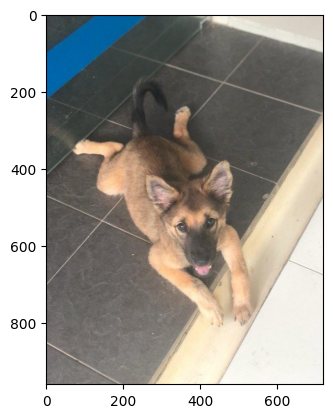

In [15]:
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)



In [16]:
for a in tmpdf[tmpdf[0] == True].index:
    print("・" + a)



・Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・Decently clear face, facing front or near-front
・Single pet taking up significant portion of photo (roughly over 50% of photo width or height)


In [17]:
tmpdf[tmpdf[0] == False]



,0
"Pet stands out against uncluttered background, not too close / far",0
"Pet in the middle of an action (e.g., jumping)",0
"Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash",0
More than 1 pet in the photo,0
"Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)",0
Human in the photo,0
"Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion",0
"Custom-added text or labels (i.e. pet name, description)",0
"Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entries, “Eyes” column is always set to 0",0


In [18]:
for a in tmpdf[tmpdf[0] == False].index:
    print("・" + a)



・Pet stands out against uncluttered background, not too close / far
・Pet in the middle of an action (e.g., jumping)
・Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・More than 1 pet in the photo
・Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・Human in the photo
・Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・Custom-added text or labels (i.e. pet name, description)
・Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entries, “Eyes” column is always set to 0


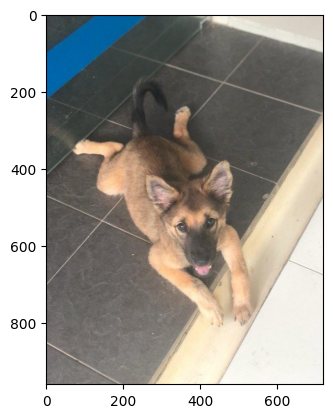

--------Pawpularity------------
55
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

In [19]:
path = os.path.join(train_path, train["Id"].iloc[0] + ".jpg")

plt.figure()

img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

plt.show()

tmpdf = train_eng[train_eng.index == 0].T

print("--------Pawpularity------------")
print(tmpdf[0].iloc[-1])

print("--------item Number 1------------")
for a in tmpdf[tmpdf[0] == True].index:
    print("・ " + a)

print("")
print("--------item Number 0------------")
for a in tmpdf[tmpdf[0] == False].index:
    print("・ " + a)




In [20]:
def showimg(id):

    plt.figure()
    path = os.path.join(train_path, train["Id"].iloc[id] + ".jpg")

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)

    plt.show()

    tmpdf = train_eng[train_eng.index == id].T

    print("--------Pawpularity------------")
    print(tmpdf[id].iloc[-1])

    print("--------item Number 1------------")
    for a in tmpdf[tmpdf[id] == True].index:
        if a == "Pawpularity":
            continue
        print("・ " + a)

    print("")
    print("--------item Number 0------------")
    for a in tmpdf[tmpdf[id] == False].index:
        if a == "Pawpularity":
            continue
        print("・ " + a)




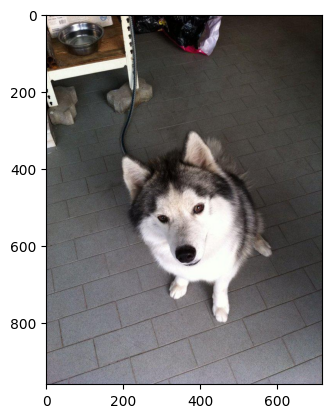

--------Pawpularity------------
100
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur ent

In [21]:
showimg(1)



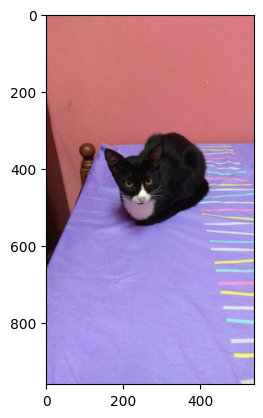

--------Pawpularity------------
27
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

In [22]:
showimg(2)



In [23]:
train[train["Pawpularity"] == 100]



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
76,28e97352c4a2d1967aa45c7f7b461a45,0,0,1,1,0,0,0,0,0,0,0,0,100
126,1791180369993a28ea50e8efb7d48fbc,0,1,1,1,0,0,0,0,0,0,0,0,100
169,33aeda930a4aa1525940a758aee6122a,0,1,1,1,0,0,0,0,0,0,0,0,100
170,a89fb15d3fc39562358d5cdeb31a5136,0,1,1,1,0,0,0,0,0,0,0,0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8803,d68d07de825adcadc895c52626d7b55f,0,1,1,1,0,0,0,0,0,0,0,0,100
8839,9b968a0678a480ba9ff6a6872c4f258e,0,1,1,1,0,0,0,0,0,0,0,0,100
8875,9fb4989f469ccfa8e6eb0f394939350d,0,0,1,1,0,0,0,0,0,0,0,1,100
8890,132437a04cfc62c5b8c72b035e1aa5e6,0,1,1,0,0,0,0,1,0,0,0,0,100


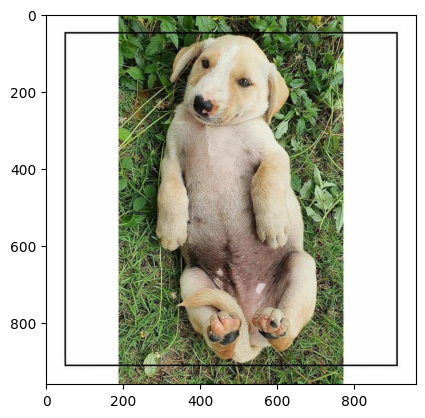

--------Pawpularity------------
39
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

In [24]:
showimg(19)



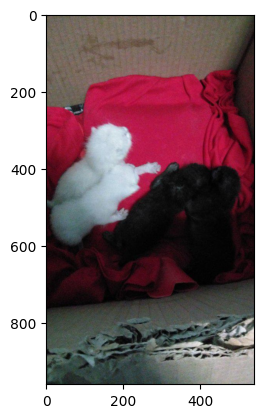

--------Pawpularity------------
65
--------item Number 1------------
・ More than 1 pet in the photo
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entries, “Eyes” column is always set to 0

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text o

In [25]:
showimg(50)



In [26]:
train[train["Pawpularity"] == 1]



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
1283,53b536999aecd800cfda720f3ca363cb,0,1,1,1,0,0,0,0,0,0,0,0,1
1431,6c159aede3df25fdbe781431aabcfc67,0,1,1,1,0,0,0,0,0,0,0,0,1
2255,e0a1efdaf4fbed8659b6d23994ee346e,0,1,1,1,0,0,0,0,1,1,0,0,1
6486,3ed899a8334a8e5c74f4a554f3ce6f08,0,1,1,1,0,0,0,0,0,0,0,0,1


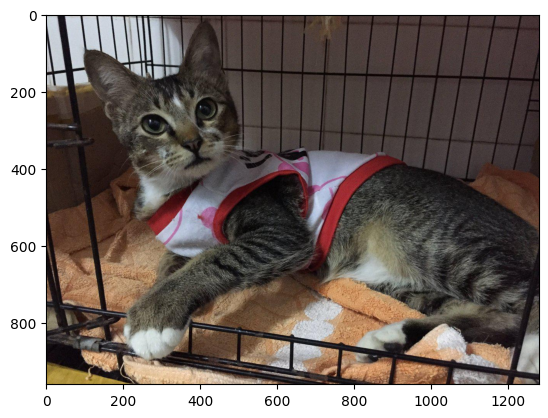

--------Pawpularity------------
20
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

In [27]:
showimg(2442)



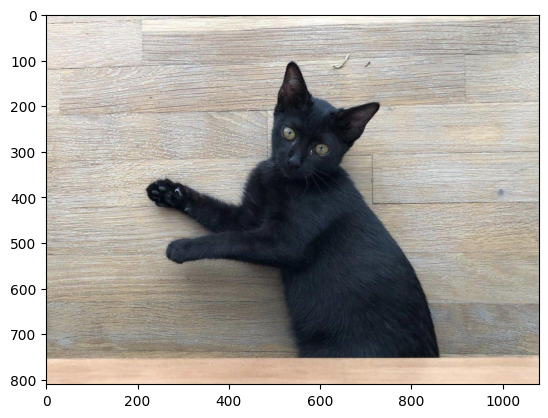

--------Pawpularity------------
15
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

In [28]:
showimg(3232)



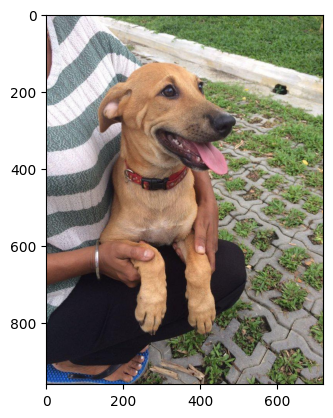

--------Pawpularity------------
23
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

In [29]:
showimg(4235)



In [30]:
tmpdf3 = train.groupby("Pawpularity").head(1).sort_values("Pawpularity").reset_index()
tmpdf3



,index,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1283,53b536999aecd800cfda720f3ca363cb,0,1,1,1,0,0,0,0,0,0,0,0,1
1,190,8d25de72c44ddfa6d4d39135c1d75fd7,0,1,1,1,0,0,0,0,0,0,0,0,2
2,14,211e20b7a15b4a3fb01d04cb25bd9c95,0,1,1,1,0,0,0,0,0,0,1,0,3
3,340,adf00ba782d2e4408dbb4908d462e3dc,0,1,1,1,0,1,0,0,0,1,0,0,4
4,90,916ce20c02cd4ef9225d7dbabde68f1c,0,1,1,1,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,542,48a66727373de4e7fa7bb3331cd9acc8,0,0,1,1,1,0,0,0,0,0,0,1,96
96,1219,1dcb4ca27c42a695618c73e53d983d9e,0,0,0,0,0,0,0,0,0,0,0,0,97
97,167,3e49e03d5e33e634a4eb798696d51577,0,1,1,1,0,0,0,0,0,0,0,0,98
98,2932,ec07599018885a44734a9ba27d306055,0,1,1,1,0,0,0,0,0,0,0,0,99


In [31]:
tmpdf4 = tmpdf3.iloc[::10, :]
tmpdf4



,index,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1283,53b536999aecd800cfda720f3ca363cb,0,1,1,1,0,0,0,0,0,0,0,0,1
10,114,942bbeca4342a9c4f94946966c874ef4,0,1,1,1,0,1,0,1,0,0,1,0,11
20,18,f7b3d30fc64460a4870e8a1ce272d18b,0,0,0,1,0,0,0,0,0,0,0,0,21
30,16,3c602cbcb19db7a0998e1411082c487d,0,1,1,1,0,0,0,0,0,0,0,0,31
40,48,8cd1ee098fbfbce6dcdc377d89ac4862,0,1,1,1,0,0,0,0,0,0,0,0,41
50,3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
60,181,20cf3a2938ac42d1d4f0bf182ce6668e,0,1,1,1,0,0,0,0,0,0,0,0,61
70,108,5ee606dfd740ca246d0033299bdd722b,1,1,1,1,0,0,0,0,0,0,0,0,71
80,928,db010c8900095ee6504d111f21538ec6,0,0,1,1,0,1,0,0,0,0,0,0,81
90,119,eeaa15c5152614b7cd793f9e52ae07e9,0,1,1,1,0,0,0,0,0,0,0,0,91


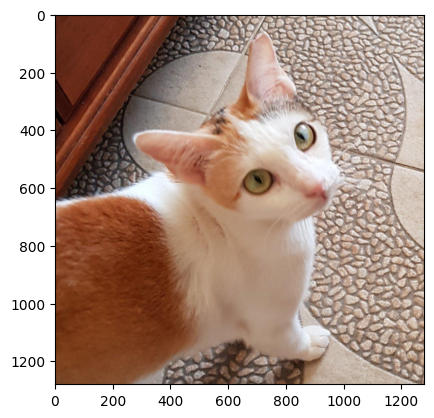

--------Pawpularity------------
1
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)
・ an index of the popularity (attractiveness) of pets

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, 

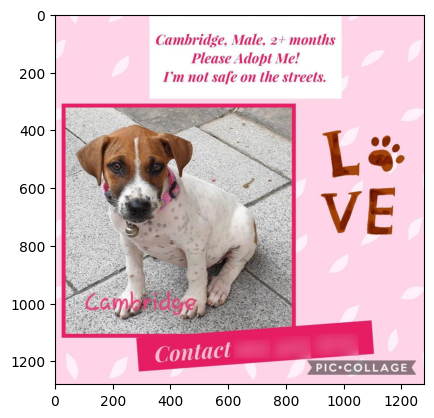

--------Pawpularity------------
11
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Custom-added text or labels (i.e. pet name, description)

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ More than 1 pet in the photo
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

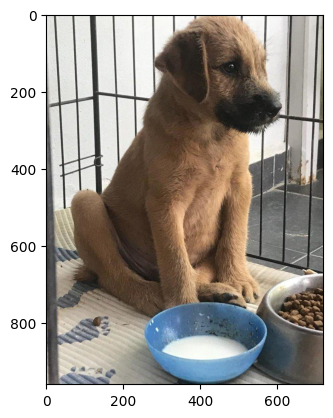

--------Pawpularity------------
21
--------item Number 1------------
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

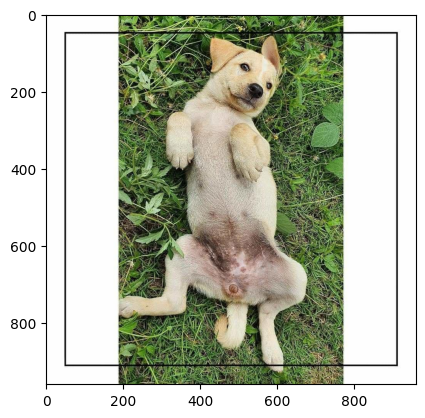

--------Pawpularity------------
31
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

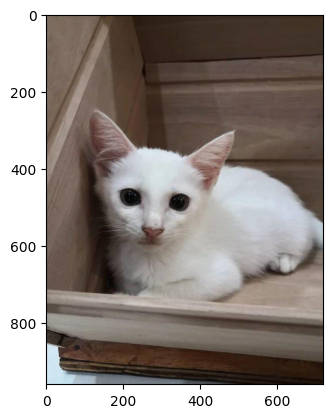

--------Pawpularity------------
41
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

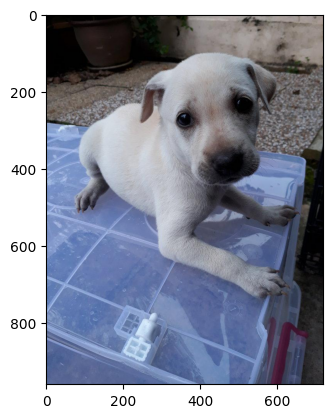

--------Pawpularity------------
51
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

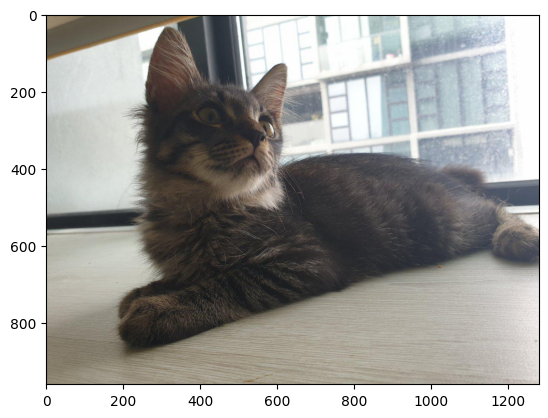

--------Pawpularity------------
61
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

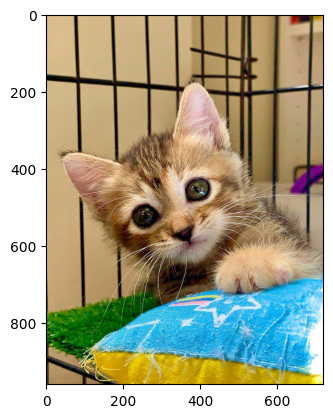

--------Pawpularity------------
71
--------item Number 1------------
・ Pet stands out against uncluttered background, not too close / far
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)

--------item Number 0------------
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

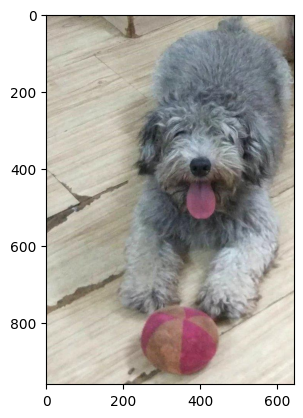

--------Pawpularity------------
81
--------item Number 1------------
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Pet in the middle of an action (e.g., jumping)
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

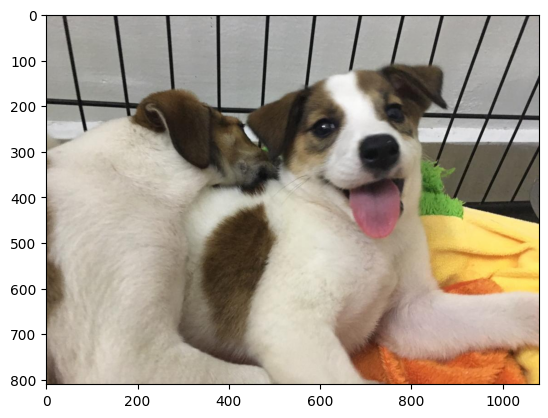

--------Pawpularity------------
91
--------item Number 1------------
・ Both eyes are facing front or near-front, with at least 1 eye / pupil decently clear
・ Decently clear face, facing front or near-front
・ Single pet taking up significant portion of photo (roughly over 50% of photo width or height)

--------item Number 0------------
・ Pet stands out against uncluttered background, not too close / far
・ Pet in the middle of an action (e.g., jumping)
・ Accompanying physical or digital accessory / prop (i.e. toy, digital sticker), excluding collar and leash
・ More than 1 pet in the photo
・ Digitally-retouched photo (i.e. with digital photo frame, combination of multiple photos)
・ Human in the photo
・ Specific undesirable objects blocking part of the pet (i.e. human, cage or fence). Note that not all blocking objects are considered occlusion
・ Custom-added text or labels (i.e. pet name, description)
・ Noticeably out of focus or noisy, especially for the pet’s eyes and face. For Blur entr

In [32]:
# NOTE: This loop is heavy; keeping it as-is for logic preservation.
# In Kaggle notebooks you can comment it out to save time if needed.
for a in tmpdf4["index"]:
    showimg(a)
    print("")
    print("#################################################")



In [33]:
train



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8915,ee97d86d26506239666d3679ff4a73aa,0,0,1,1,0,0,0,0,0,0,0,1,31
8916,7cf13d655a8d0d6a1d636c3920d49e86,0,0,1,1,0,0,0,0,0,0,0,0,33
8917,547e443edbf94b3646ff110324846bae,0,1,1,0,0,0,1,0,0,0,0,0,27
8918,fe2b587f649b9780900246c4b174a231,0,1,1,1,0,0,1,0,0,0,0,0,27


In [34]:
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold



In [35]:
folds = train.copy()
Fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for n, (train_index, val_index) in enumerate(Fold.split(folds, folds["Pawpularity"])):
    folds.loc[val_index, "fold"] = int(n)
folds["fold"] = folds["fold"].astype(int)
print(folds.groupby(["fold", "Pawpularity"]).size())



fold  Pawpularity
0     1               1
      2              13
      3              16
      4               7
      5               7
                     ..
4     96              2
      97              1
      98              1
      99              1
      100            53
Length: 498, dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


In [36]:
import lightgbm as lgb



In [37]:
import random


def fix_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


SEED = 42
fix_seed(SEED)



In [38]:
features = train.columns.to_list()[1:-1]
features



['Subject Focus',
 'Eyes',
 'Face',
 'Near',
 'Action',
 'Accessory',
 'Group',
 'Collage',
 'Human',
 'Occlusion',
 'Info',
 'Blur']

In [39]:
target = "Pawpularity"



In [40]:
lgbm_params = {
    "objective": "rmse",
    "seed": 42,
    "metric": "rmse",
    "learning_rate": 0.01,
    "max_bin": 800,
    "num_leaves": 80,
    "verbose": -1,
}



In [41]:
from sklearn.metrics import mean_squared_error


def rmsescore(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))




In [42]:
test



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur
0,ee51b99832f1ba868f646df93d2b6b81,0,1,1,1,0,0,0,0,0,0,0,0
1,caddfb3f8bff9c4b95dbe022018eea21,0,0,1,1,0,1,1,0,0,0,0,0
2,582eeabd4a448a53ebb79995888a4b0b,0,1,1,0,0,0,0,0,0,0,0,0
3,afc1ad7f0c5eea880759d09e77f7deee,0,1,1,1,0,0,0,0,0,0,0,0
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,0,1,1,0,0,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,46bcb1c4ca0b78c584d7a65e1b4b2590,0,1,1,1,0,0,1,0,0,0,0,0
988,8064261ce5f7197fdc849641b3192eef,0,1,1,1,0,0,0,0,0,1,0,0
989,a5ff4923e393fa08e67da31c7eb4edd5,0,1,1,1,0,0,0,0,0,0,0,0
990,fa6a53f962225c17b22392748f91f9ac,0,1,1,1,0,0,0,0,0,0,0,0


In [43]:
# Fixes LightGBM v4.6 API: use callbacks for logging and early stopping (instead of verbose_eval/early_stopping_rounds).
scores = []
allpreds = []

allvaliddf = pd.DataFrame()

for fold in range(5):
    fix_seed(SEED)  # for repetability

    p_train = folds[folds["fold"] != fold].reset_index(drop=True)
    p_val = folds[folds["fold"] == fold].reset_index(drop=True)

    lgb_train = lgb.Dataset(p_train[features], label=p_train[target])
    lgb_eval = lgb.Dataset(p_val[features], label=p_val[target], reference=lgb_train)

    callbacks = [
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=50),
    ]

    model = lgb.train(
        params=lgbm_params,
        train_set=lgb_train,
        valid_sets=[lgb_eval],
        num_boost_round=1000,
        callbacks=callbacks,
    )

    import pickle

    model_name = f"LGBMmodel{fold}.bin"
    with open(model_name, "wb") as f:
        pickle.dump(model, f)
    with open(model_name, "rb") as f:
        model = pickle.load(f)

    oof_pred = model.predict(p_val[features], num_iteration=model.best_iteration)
    scores.append(rmsescore(p_val[target], oof_pred))

    preds = model.predict(test[features], num_iteration=model.best_iteration)
    allpreds.append(preds)

    p_val = p_val.copy()
    p_val["preds"] = oof_pred
    allvaliddf = pd.concat([allvaliddf, p_val], axis=0, ignore_index=True)



Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 20.6222
[100]	valid_0's rmse: 20.6282
Early stopping, best iteration is:
[24]	valid_0's rmse: 20.6184
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 20.7245
[100]	valid_0's rmse: 20.7545
Early stopping, best iteration is:
[13]	valid_0's rmse: 20.7112
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 20.7009
[100]	valid_0's rmse: 20.6889
[150]	valid_0's rmse: 20.6827
[200]	valid_0's rmse: 20.6818
[250]	valid_0's rmse: 20.6853
Early stopping, best iteration is:
[169]	valid_0's rmse: 20.6808
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 20.5826
[100]	valid_0's rmse: 20.5913
[150]	valid_0's rmse: 20.6103
Early stopping, best iteration is:
[54]	valid_0's rmse: 20.5824
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 20.5534
[100]	valid_0's rmse: 20.5764
Early stopping, be

In [44]:
scores



[20.618432283189083,
 20.71117871780695,
 20.68082350670989,
 20.58235999839343,
 20.545574207229958]

In [45]:
np.mean(scores)



20.627673742665863

In [46]:
# Will work now because allvaliddf is populated after successful training.
rmsescore(allvaliddf[target], allvaliddf["preds"])



20.62776428613308

In [47]:
allpreds = np.mean(allpreds, axis=0)



In [48]:
# Submission validity fix: competition requires 1..100.
allpreds = np.clip(allpreds, 1, 100)



In [49]:
sample["Pawpularity"] = allpreds



In [50]:
sample.to_csv("submission.csv", index=False)



In [51]:
sample

,Id,Pawpularity
0,ee51b99832f1ba868f646df93d2b6b81,38.006696
1,caddfb3f8bff9c4b95dbe022018eea21,39.882235
2,582eeabd4a448a53ebb79995888a4b0b,37.507933
3,afc1ad7f0c5eea880759d09e77f7deee,38.006696
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,36.718307
...,...,...
987,46bcb1c4ca0b78c584d7a65e1b4b2590,37.599720
988,8064261ce5f7197fdc849641b3192eef,37.471894
989,a5ff4923e393fa08e67da31c7eb4edd5,38.006696
990,fa6a53f962225c17b22392748f91f9ac,38.006696
